In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, LineString, Polygon
from pathlib import Path

np.random.seed(42)
Path("data").mkdir(exist_ok=True)
CRS = "EPSG:25832"

# Munich Schwabing centroid (UTM 32N)
cx, cy = 691500, 5337500
SPREAD = 1200

def rand_pts(n, spread=SPREAD):
    return np.column_stack([
        cx + np.random.uniform(-spread, spread, n),
        cy + np.random.uniform(-spread, spread, n)
    ])

# ── Walk network ──────────────────────────────────────────────
pts = rand_pts(600)
lines = [LineString([pts[i], pts[i+1]]) for i in range(0, len(pts)-1, 2)]
edges_walk = gpd.GeoDataFrame({
    "highway": np.random.choice(["footway","residential","path","pedestrian"], len(lines)),
    "length_m": [l.length for l in lines],
    "speed_kph": np.random.choice([3,4,5], len(lines))
}, geometry=lines, crs=CRS)
edges_walk.to_file("data/walk_network.geojson", driver="GeoJSON")
print(f"✓ Walk edges: {len(edges_walk)}")

# ── Bike network ──────────────────────────────────────────────
pts2 = rand_pts(400)
lines2 = [LineString([pts2[i], pts2[i+1]]) for i in range(0, len(pts2)-1, 2)]
edges_bike = gpd.GeoDataFrame({
    "highway": np.random.choice(["cycleway","residential","path"], len(lines2)),
    "length_m": [l.length for l in lines2],
    "bike_infra": np.random.choice(["dedicated","shared","lane"], len(lines2))
}, geometry=lines2, crs=CRS)
edges_bike.to_file("data/bike_network.geojson", driver="GeoJSON")
print(f"✓ Bike edges: {len(edges_bike)}")

# ── PT stops ──────────────────────────────────────────────────
n_stops = 80
sxy = rand_pts(n_stops, spread=SPREAD*0.9)
stop_types = np.random.choice(["bus","tram","subway","s-bahn"], n_stops, p=[0.4,0.3,0.2,0.1])
pt_stops = gpd.GeoDataFrame({
    "name": [f"Stop {i+1}" for i in range(n_stops)],
    "public_transport": "stop_position",
    "mode": stop_types
}, geometry=[Point(x,y) for x,y in sxy], crs=CRS)
pt_stops.to_file("data/pt_stops.geojson", driver="GeoJSON")
print(f"✓ PT stops:  {len(pt_stops)}")

# ── Facilities ────────────────────────────────────────────────
fac_types = (["hospital"]*4 + ["school"]*8 + ["supermarket"]*12 +
             ["pharmacy"]*10 + ["park"]*10 + ["library"]*4 +
             ["university"]*3 + ["playground"]*9)
n_fac = len(fac_types)
fxy = rand_pts(n_fac, spread=SPREAD*0.95)
facilities = gpd.GeoDataFrame({
    "name": [f"{t.title()} {i+1}" for i,t in enumerate(fac_types)],
    "facility_type": fac_types
}, geometry=[Point(x,y) for x,y in fxy], crs=CRS)
facilities.to_file("data/facilities.geojson", driver="GeoJSON")
print(f"✓ Facilities: {len(facilities)}")

# ── Study area boundary ───────────────────────────────────────
boundary = gpd.GeoDataFrame(
    {"name": ["Schwabing, Munich"]},
    geometry=[Polygon([
        (cx-SPREAD, cy-SPREAD),(cx+SPREAD, cy-SPREAD),
        (cx+SPREAD, cy+SPREAD),(cx-SPREAD, cy+SPREAD)
    ])], crs=CRS)
boundary.to_file("data/study_area.geojson", driver="GeoJSON")
print(f"✓ Study area saved")

print("\n✓ All data files ready — now run 02, 03, 04")

✓ Walk edges: 300
✓ Bike edges: 200
✓ PT stops:  80
✓ Facilities: 60
✓ Study area saved

✓ All data files ready — now run 02, 03, 04


In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pathlib import Path

CRS        = "EPSG:25832"
DATA_DIR   = Path("data")

WALK_THRESHOLDS  = [300, 500, 800]
CYCLE_THRESHOLDS = [500, 1000, 2000]

# Load data
print("Loading data ...")
pt_stops   = gpd.read_file(DATA_DIR / "pt_stops.geojson").to_crs(CRS)
facilities = gpd.read_file(DATA_DIR / "facilities.geojson").to_crs(CRS)
boundary   = gpd.read_file(DATA_DIR / "study_area.geojson").to_crs(CRS)
print(f"  PT stops   : {len(pt_stops)}")
print(f"  Facilities : {len(facilities)}")

# Walking catchments
print("\nBuilding walking catchment polygons ...")
walk_catchments = {}
for dist in WALK_THRESHOLDS:
    buffers = pt_stops.geometry.buffer(dist)
    merged  = unary_union(buffers)
    clipped = merged.intersection(boundary.union_all())
    walk_catchments[dist] = clipped
    print(f"  {dist:>4}m walk → {clipped.area/10_000:.1f} ha")

# Cycling catchments
print("\nBuilding cycling catchment polygons ...")
cycle_catchments = {}
for dist in CYCLE_THRESHOLDS:
    buffers = pt_stops.geometry.buffer(dist)
    merged  = unary_union(buffers)
    clipped = merged.intersection(boundary.union_all())
    cycle_catchments[dist] = clipped
    print(f"  {dist:>4}m cycle → {clipped.area/10_000:.1f} ha")

# Nearest PT stop per facility
print("\nCalculating nearest PT stop distances ...")
fac_coords  = np.array([(g.x, g.y) for g in facilities.geometry])
stop_coords = np.array([(g.x, g.y) for g in pt_stops.geometry])
tree = cKDTree(stop_coords)
dists, idxs = tree.query(fac_coords, k=1)

facilities = facilities.copy()
facilities["dist_to_pt_m"]      = dists.round(1)
facilities["nearest_stop_name"] = pt_stops.iloc[idxs]["name"].values
facilities["walk_accessible"]   = dists <= 500
facilities["cycle_accessible"]  = dists <= 1000

# Coverage statistics
print("\nComputing coverage statistics ...")
study_area_ha = boundary.union_all().area / 10_000
rows = []
for dist in WALK_THRESHOLDS:
    covered = walk_catchments[dist].area / 10_000
    rows.append({"mode": "walk", "threshold_m": dist,
                 "catchment_ha": round(covered, 1),
                 "pct_study_area": round(100 * covered / study_area_ha, 1)})
for dist in CYCLE_THRESHOLDS:
    covered = cycle_catchments[dist].area / 10_000
    rows.append({"mode": "cycle", "threshold_m": dist,
                 "catchment_ha": round(covered, 1),
                 "pct_study_area": round(100 * covered / study_area_ha, 1)})

coverage_df = pd.DataFrame(rows)
coverage_df.to_csv(DATA_DIR / "coverage_stats.csv", index=False)
print(coverage_df.to_string(index=False))

# Facility type summary
summary = (facilities
    .groupby("facility_type")[["walk_accessible","cycle_accessible"]]
    .agg(["sum","count"]))
summary.columns = ["walk_n","walk_total","cycle_n","cycle_total"]
summary["walk_pct"]  = (100 * summary["walk_n"]  / summary["walk_total"]).round(1)
summary["cycle_pct"] = (100 * summary["cycle_n"] / summary["cycle_total"]).round(1)
summary.to_csv(DATA_DIR / "facility_accessibility_summary.csv")
print("\nAccessibility by facility type:")
print(summary.to_string())

# Save outputs
facilities.to_file(DATA_DIR / "accessibility_results.geojson", driver="GeoJSON")

catchment_rows = []
for dist, geom in walk_catchments.items():
    catchment_rows.append({"mode": "walk",  "threshold_m": dist, "geometry": geom})
for dist, geom in cycle_catchments.items():
    catchment_rows.append({"mode": "cycle", "threshold_m": dist, "geometry": geom})
catchments_gdf = gpd.GeoDataFrame(catchment_rows, crs=CRS)
catchments_gdf.to_file(DATA_DIR / "catchments.geojson", driver="GeoJSON")

print("\n✓ All results saved to ./data/")

Loading data ...
  PT stops   : 80
  Facilities : 60

Building walking catchment polygons ...
   300m walk → 540.2 ha
   500m walk → 575.6 ha
   800m walk → 576.0 ha

Building cycling catchment polygons ...
   500m cycle → 575.6 ha
  1000m cycle → 576.0 ha
  2000m cycle → 576.0 ha

Calculating nearest PT stop distances ...

Computing coverage statistics ...
 mode  threshold_m  catchment_ha  pct_study_area
 walk          300         540.2            93.8
 walk          500         575.6            99.9
 walk          800         576.0           100.0
cycle          500         575.6            99.9
cycle         1000         576.0           100.0
cycle         2000         576.0           100.0

Accessibility by facility type:
               walk_n  walk_total  cycle_n  cycle_total  walk_pct  cycle_pct
facility_type                                                               
hospital            4           4        4            4     100.0      100.0
library             4           4

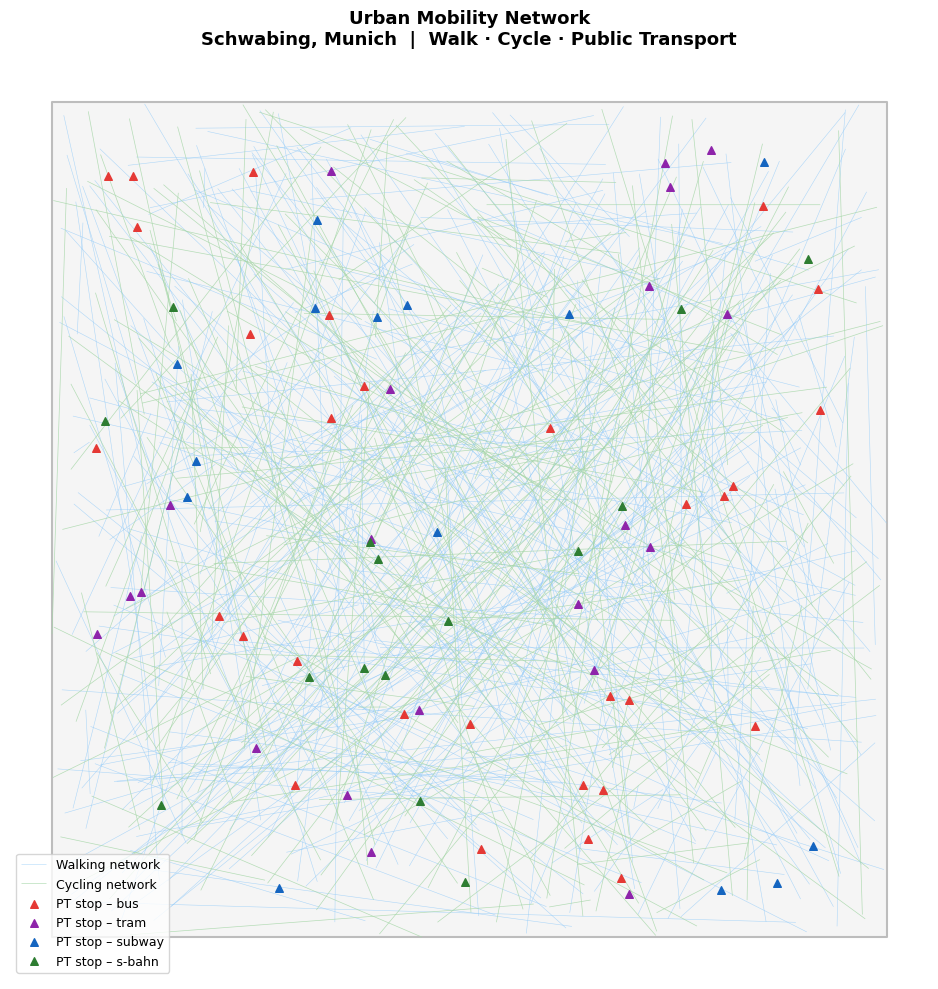

✓ Map 1 saved


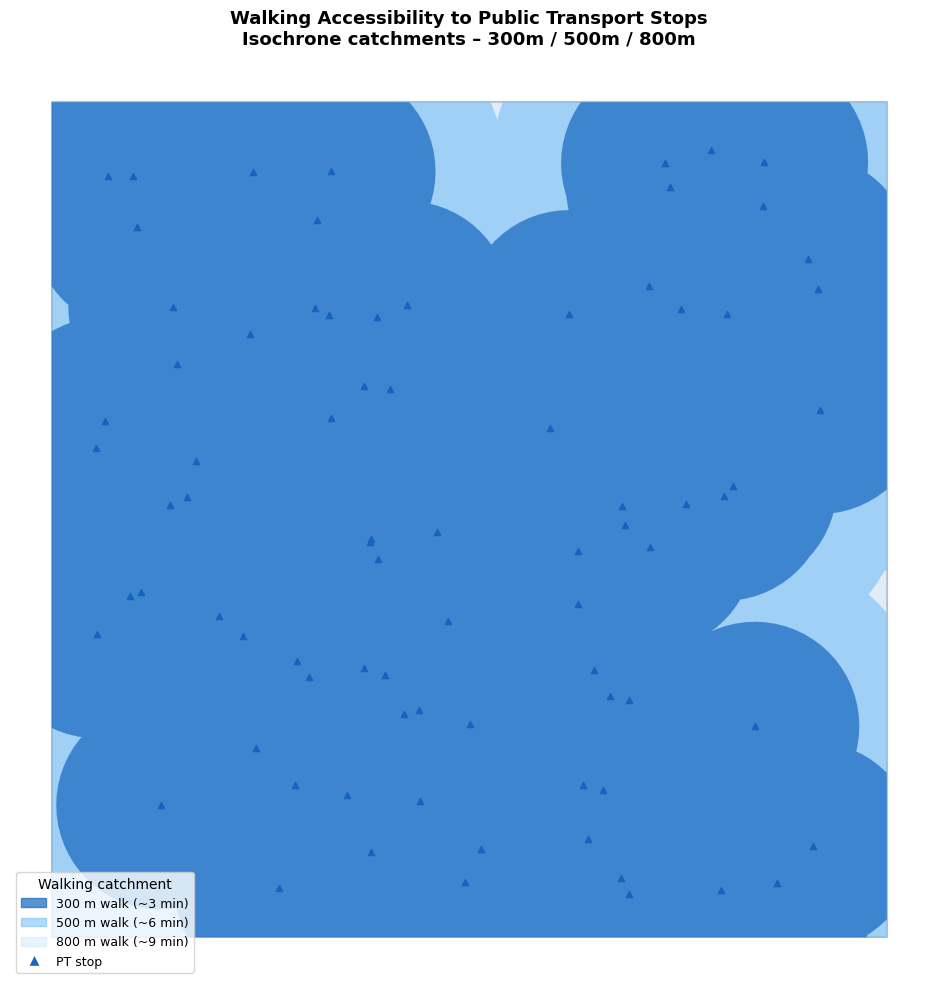

✓ Map 2 saved


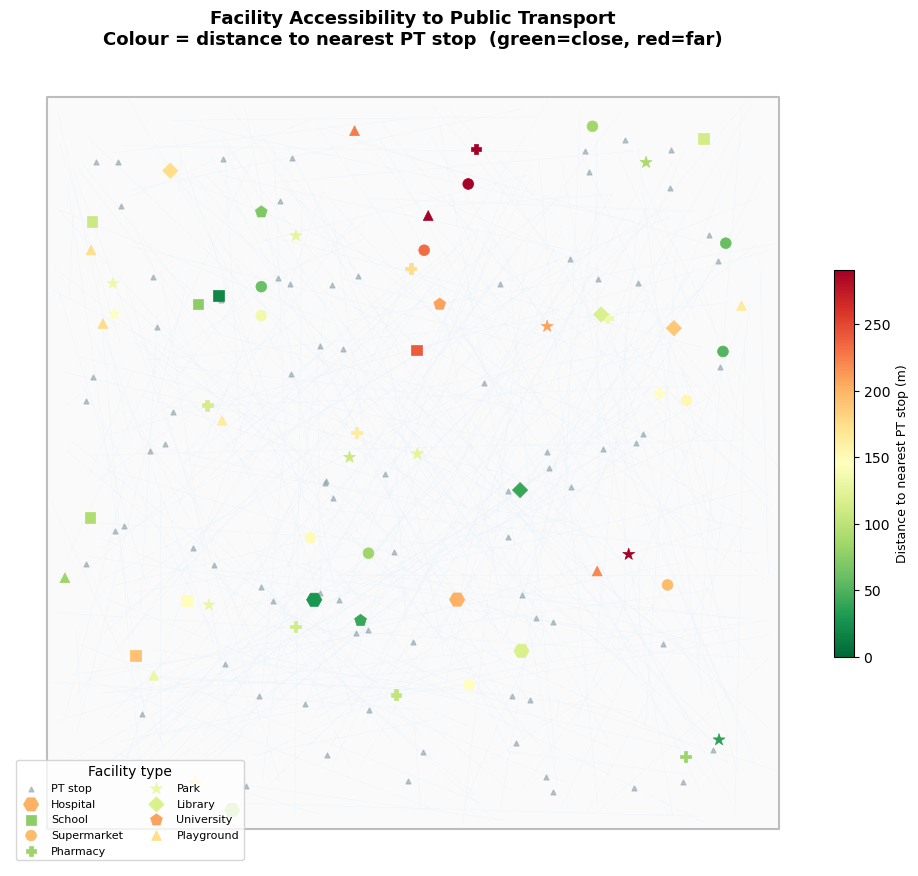

✓ Map 3 saved


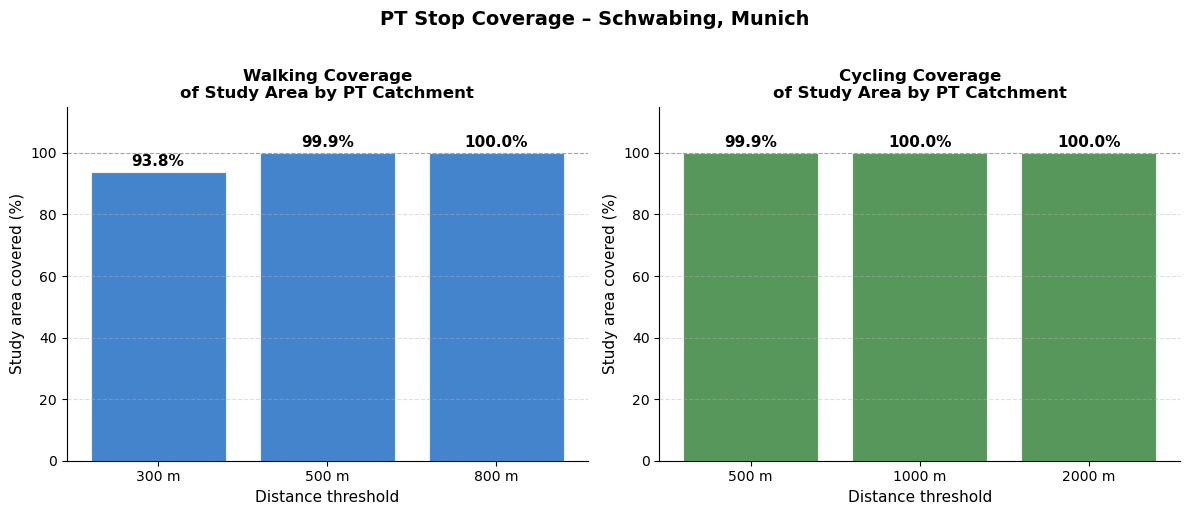

✓ Chart 4 saved

✓ All maps saved to ./outputs/


In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

CRS        = "EPSG:25832"
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"font.family": "sans-serif",
                     "axes.spines.top": False,
                     "axes.spines.right": False})

# Load all layers
walk_net   = gpd.read_file(DATA_DIR / "walk_network.geojson").to_crs(CRS)
bike_net   = gpd.read_file(DATA_DIR / "bike_network.geojson").to_crs(CRS)
pt_stops   = gpd.read_file(DATA_DIR / "pt_stops.geojson").to_crs(CRS)
facilities = gpd.read_file(DATA_DIR / "accessibility_results.geojson").to_crs(CRS)
catchments = gpd.read_file(DATA_DIR / "catchments.geojson").to_crs(CRS)
boundary   = gpd.read_file(DATA_DIR / "study_area.geojson").to_crs(CRS)
coverage   = pd.read_csv(DATA_DIR / "coverage_stats.csv")

MODE_COLORS = {"bus": "#E53935", "tram": "#8E24AA",
               "subway": "#1565C0", "s-bahn": "#2E7D32"}

# ── MAP 1: Network overview ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
boundary.plot(ax=ax, color="#F5F5F5", edgecolor="#BDBDBD", linewidth=1.5, zorder=1)
walk_net.plot(ax=ax, color="#90CAF9", linewidth=0.4, alpha=0.7, zorder=2, label="Walking network")
bike_net.plot(ax=ax, color="#A5D6A7", linewidth=0.5, alpha=0.8, zorder=3, label="Cycling network")
for mode, color in MODE_COLORS.items():
    sub = pt_stops[pt_stops["mode"] == mode]
    if len(sub):
        sub.plot(ax=ax, color=color, markersize=30, marker="^",
                 zorder=5, label=f"PT stop – {mode}")
ax.set_title("Urban Mobility Network\nSchwabing, Munich  |  Walk · Cycle · Public Transport",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower left", frameon=True, fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "map1_network_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Map 1 saved")

# ── MAP 2: Walking isochrones ─────────────────────────────────
walk_catches = catchments[catchments["mode"] == "walk"].copy()
walk_catches["threshold_m"] = walk_catches["threshold_m"].astype(int)
walk_catches = walk_catches.sort_values("threshold_m", ascending=False)

ISOCHRONE_COLORS = {800: "#BBDEFB", 500: "#64B5F6", 300: "#1565C0"}
ISOCHRONE_ALPHA  = {800: 0.35,      500: 0.50,      300: 0.70}

fig, ax = plt.subplots(figsize=(10, 10))
boundary.plot(ax=ax, color="#F5F5F5", edgecolor="#BDBDBD", linewidth=1.5, zorder=1)
for _, row in walk_catches.iterrows():
    d = int(row["threshold_m"])
    gpd.GeoDataFrame([row], crs=CRS).plot(
        ax=ax, color=ISOCHRONE_COLORS[d], alpha=ISOCHRONE_ALPHA[d], zorder=2)
pt_stops.plot(ax=ax, color="#1565C0", markersize=20, marker="^", zorder=4)
legend_patches = [
    mpatches.Patch(color=ISOCHRONE_COLORS[d], alpha=ISOCHRONE_ALPHA[d],
                   label=f"{d} m walk (~{d//83} min)")
    for d in [300, 500, 800]
]
legend_patches.append(
    plt.Line2D([0],[0], marker="^", color="w",
               markerfacecolor="#1565C0", markersize=8, label="PT stop"))
ax.legend(handles=legend_patches, loc="lower left", frameon=True,
          fontsize=9, title="Walking catchment")
ax.set_title("Walking Accessibility to Public Transport Stops\nIsochrone catchments – 300m / 500m / 800m",
             fontsize=13, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "map2_walk_isochrones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Map 2 saved")

# ── MAP 3: Facility accessibility dot map ─────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
boundary.plot(ax=ax, color="#FAFAFA", edgecolor="#BDBDBD", linewidth=1.5, zorder=1)
walk_net.plot(ax=ax, color="#E3F2FD", linewidth=0.3, alpha=0.6, zorder=2)
pt_stops.plot(ax=ax, color="#90A4AE", markersize=12, marker="^",
              alpha=0.6, zorder=3, label="PT stop")
norm = mcolors.Normalize(vmin=0, vmax=facilities["dist_to_pt_m"].quantile(0.95))
cmap = cm.RdYlGn_r
FTYPE_MARKERS = {
    "hospital":    ("H", 120), "school":      ("s", 60),
    "supermarket": ("o", 60),  "pharmacy":    ("P", 60),
    "park":        ("*", 80),  "library":     ("D", 60),
    "university":  ("p", 80),  "playground":  ("^", 50),
}
for ftype, (marker, size) in FTYPE_MARKERS.items():
    sub = facilities[facilities["facility_type"] == ftype]
    if len(sub):
        c = [cmap(norm(d)) for d in sub["dist_to_pt_m"]]
        ax.scatter(sub.geometry.x, sub.geometry.y,
                   c=c, s=size, marker=marker, zorder=5,
                   linewidths=0.5, label=ftype.title())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Distance to nearest PT stop (m)", fontsize=9)
ax.legend(loc="lower left", frameon=True, fontsize=8, title="Facility type", ncol=2)
ax.set_title("Facility Accessibility to Public Transport\nColour = distance to nearest PT stop  (green=close, red=far)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "map3_facility_accessibility.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Map 3 saved")

# ── CHART 4: Coverage bar chart ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mode, color in zip(axes, ["walk", "cycle"], ["#1565C0", "#2E7D32"]):
    sub = coverage[coverage["mode"] == mode].sort_values("threshold_m")
    bars = ax.bar(sub["threshold_m"].astype(str) + " m",
                  sub["pct_study_area"],
                  color=color, alpha=0.8, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, sub["pct_study_area"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{val:.1f}%", ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    ax.set_ylim(0, 115)
    ax.set_xlabel("Distance threshold", fontsize=11)
    ax.set_ylabel("Study area covered (%)", fontsize=11)
    ax.set_title(f"{'Walking' if mode=='walk' else 'Cycling'} Coverage\nof Study Area by PT Catchment",
                 fontsize=12, fontweight="bold")
    ax.axhline(100, linestyle="--", color="grey", linewidth=0.8, alpha=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.suptitle("PT Stop Coverage – Schwabing, Munich",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart4_coverage_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved")

print("\n✓ All maps saved to ./outputs/")

In [3]:
# Install folium directly inside Jupyter Notebook
!pip install folium

# If geopandas is also missing, uncomment this:
# !pip install geopandas

# Restarting imports after installation
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster, MeasureControl, Fullscreen
from pathlib import Path

# Coordinate Reference System
CRS = "EPSG:4326"

# Folder paths
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Function to load GeoJSON files
def load(name):
    return gpd.read_file(DATA_DIR / name).to_crs(CRS)

# Load datasets
walk_net   = load("walk_network.geojson")
bike_net   = load("bike_network.geojson")
pt_stops   = load("pt_stops.geojson")
facilities = load("accessibility_results.geojson")
catchments = load("catchments.geojson")
boundary   = load("study_area.geojson")

# Map center (Munich example)
MAP_CENTER = [48.163, 11.574]

# Create base map
m = folium.Map(
    location=MAP_CENTER,
    zoom_start=15,
    tiles="CartoDB positron",
    control_scale=True
)

# Add fullscreen and measurement tools
Fullscreen().add_to(m)
MeasureControl(
    position="topleft",
    primary_length_unit="meters"
).add_to(m)

# Add study area boundary
fg_boundary = folium.FeatureGroup(name="Study Area", show=True)

folium.GeoJson(
    boundary.__geo_interface__,
    style_function=lambda _: {
        "fillColor": "none",
        "color": "#333333",
        "weight": 2.5,
        "dashArray": "6 4"
    }
).add_to(fg_boundary)

fg_boundary.add_to(m)

# Add PT Stops
MODE_COLORS = {
    "bus": "#E53935",
    "tram": "#8E24AA",
    "subway": "#1565C0",
    "s-bahn": "#2E7D32"
}

fg_pt = folium.FeatureGroup(name="PT Stops", show=True)
cluster = MarkerCluster().add_to(fg_pt)

for _, row in pt_stops.iterrows():
    mode = row.get("mode", "bus")
    color = MODE_COLORS.get(mode, "#607D8B")

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=7,
        color="white",
        weight=1.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=f"{row.get('name', 'Unnamed stop')} ({mode})"
    ).add_to(cluster)

fg_pt.add_to(m)

# Add walking network
fg_walk = folium.FeatureGroup(name="Walking Network", show=False)

folium.GeoJson(
    walk_net.__geo_interface__,
    style_function=lambda _: {
        "color": "#64B5F6",
        "weight": 1.0,
        "opacity": 0.6
    }
).add_to(fg_walk)

fg_walk.add_to(m)

# Add cycling network
fg_bike = folium.FeatureGroup(name="Cycling Network", show=False)

folium.GeoJson(
    bike_net.__geo_interface__,
    style_function=lambda _: {
        "color": "#66BB6A",
        "weight": 1.2,
        "opacity": 0.7
    }
).add_to(fg_bike)

fg_bike.add_to(m)

# Add layer control
folium.LayerControl(collapsed=False).add_to(m)

# Save map
out = OUTPUT_DIR / "interactive_map.html"
m.save(str(out))

print(f"✓ Interactive map saved → {out}")

# Display directly inside Jupyter Notebook
m

✓ Interactive map saved → outputs\interactive_map.html
